# Analyza vysledku pro NI-PDP

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:

res_df = pd.read_csv("bench_results_dfs_count.csv")
res_df = pd.read_csv("bench_results_no_dfs_count.csv")
mpi_df = pd.read_csv("bench_results_mpi.csv")

## Cas podle poctu vlaken

In [20]:
mpi_df['input'].unique()

array(['mapb10_10a.txt', 'mapb8_8a.txt', 'mapb8_8b.txt', 'mapb9_9a.txt',
       'mapb9_9b.txt'], dtype=object)

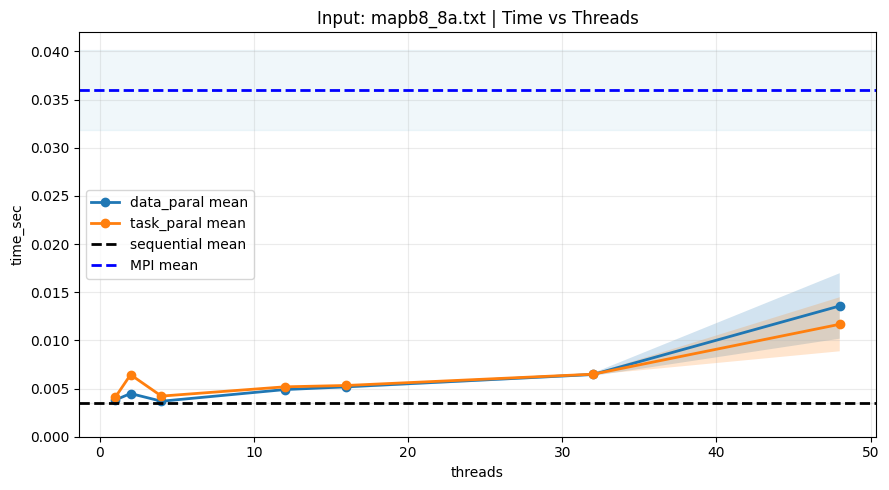

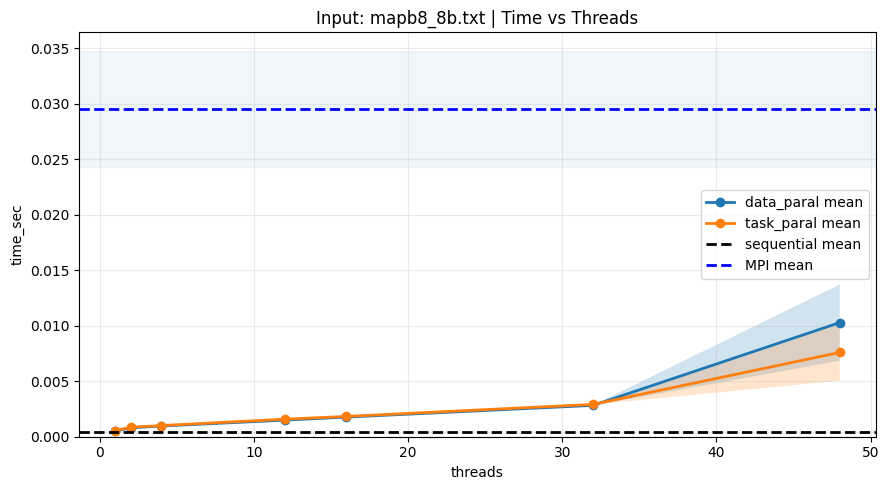

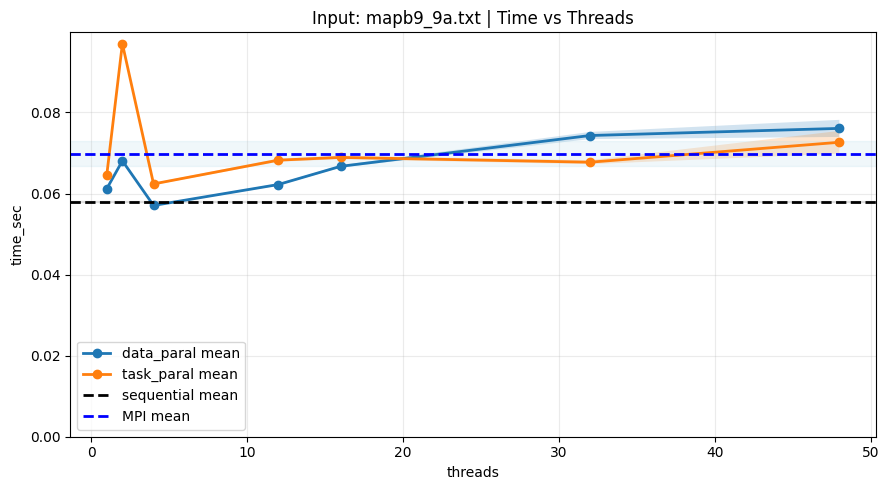

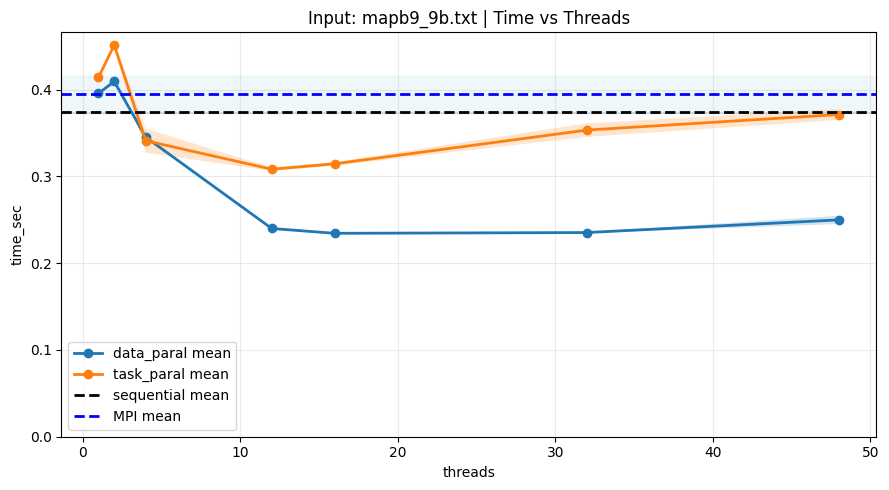

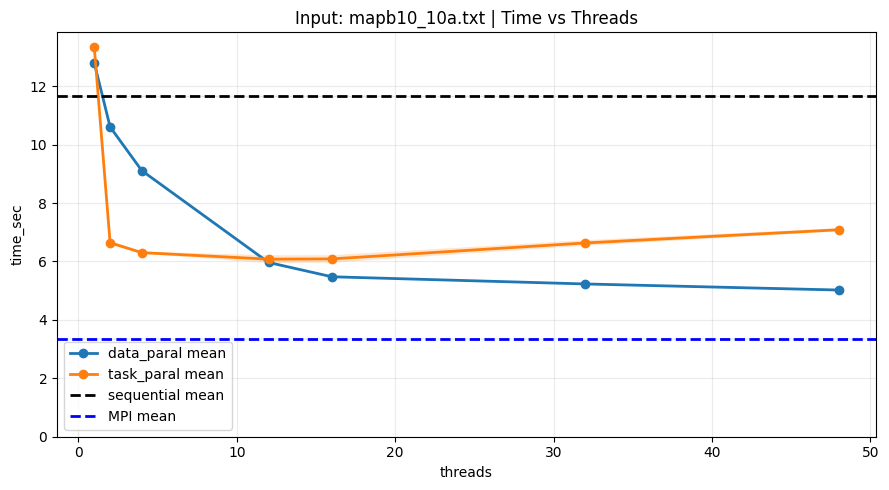

In [22]:
inputs = ['mapb8_8a.txt', 'mapb8_8b.txt', 'mapb9_9a.txt','mapb9_9b.txt', 'mapb10_10a.txt'] #mpi_df['input'].unique()

parallel_variants = ['data_paral', 'task_paral']

parallel_stats = (res_df
    [(res_df['variant'].isin(parallel_variants)) & (res_df['input'].isin(inputs))]
    .groupby(['input', 'variant', 'threads'])['time_sec']
    .agg(mean='mean', se='sem')
    .reset_index()
)

# Sequential baseline: single mean and standard error per input.
sequential_stats = (res_df
    [(res_df['variant'] == 'sequential') & (res_df['input'].isin(inputs))]
    .groupby('input')['time_sec']
    .agg(mean='mean', se='sem')
    .reset_index()
)

mpi_stats = (mpi_df
    [(mpi_df['variant'] == 'mpi') & (mpi_df['input'].isin(inputs))]
    .groupby('input')['time_sec']
    .agg(mean='mean', se='sem')
    .reset_index()
)

for input_name in inputs:
    fig, ax = plt.subplots(figsize=(9, 5))

    p_input = parallel_stats[parallel_stats['input'] == input_name]
    for variant_name, grp in p_input.groupby('variant'):
        grp = grp.sort_values('threads')
        se = grp['se'].fillna(0)

        ax.plot(grp['threads'], grp['mean'], marker='o', linewidth=2, label=f'{variant_name} mean')
        ax.fill_between(grp['threads'], grp['mean'] - se, grp['mean'] + se, alpha=0.2)

    s_input = sequential_stats[sequential_stats['input'] == input_name]
    seq_mean = s_input['mean'].iloc[0]
    seq_se = s_input['se'].iloc[0]
    if pd.isna(seq_se):
        seq_se = 0

    ax.axhline(y=seq_mean, linestyle='--', linewidth=2, color='black', label='sequential mean')
    ax.axhspan(seq_mean - seq_se, seq_mean + seq_se, color='gray', alpha=0.18)

    mpi_input = mpi_stats[mpi_stats['input'] == input_name]
    mpi_mean = mpi_input['mean'].iloc[0]
    mpi_se = mpi_input['se'].iloc[0]
    if pd.isna(mpi_se):
        mpi_se = 0

    ax.axhline(y=mpi_mean, linestyle='--', linewidth=2, color='blue', label='MPI mean')
    ax.axhspan(mpi_mean - mpi_se, mpi_mean + mpi_se, color='lightblue', alpha=0.18)

    ax.set_title(f'Input: {input_name} | Time vs Threads')
    ax.set_xlabel('threads')
    ax.set_ylabel('time_sec')
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()